# Brain Tumor Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Flatten

import warnings
warnings.filterwarnings('ignore')

### read images

In [2]:
import os
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

DATASET_PATH = "./"  # change if needed

IMG_SIZE = (128, 128)

def load_data(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder, filename)
            img = load_img(path, target_size=IMG_SIZE)
            img = img_to_array(img) / 255.0
            images.append(img)
    return np.array(images)

yes_images = load_data(os.path.join(DATASET_PATH, "yes"))
no_images = load_data(os.path.join(DATASET_PATH, "no"))

print("Yes:", yes_images.shape)
print("No:", no_images.shape)

Yes: (155, 128, 128, 3)
No: (98, 128, 128, 3)


In [3]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

X = np.concatenate([yes_images, no_images], axis=0)

y = np.concatenate([
    np.ones(len(yes_images)),
    np.zeros(len(no_images))
]).astype(int)

X_train, X_test, y_train_lbl, y_test_lbl = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

y_train = tf.keras.utils.to_categorical(y_train_lbl, 2)
y_test = tf.keras.utils.to_categorical(y_test_lbl, 2)

### Build CNN Model

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    MaxPooling2D(),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    
    Dense(2, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,872,002 (64.36 MB)

 Trainable params: 16,872,002 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

### Training and Saving of accuracy & Loss at train time and validation time

In [5]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(patience=8, restore_best_weights=True)

history = model.fit(
   
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 300ms/step - accuracy: 0.5776 - loss: 0.9158 - val_accuracy: 0.6829 - val_loss: 0.6617
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 0.7826 - loss: 0.6112 - val_accuracy: 0.8293 - val_loss: 0.5062
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.7702 - loss: 0.5138 - val_accuracy: 0.6098 - val_loss: 0.8421
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.7764 - loss: 0.5329 - val_accuracy: 0.8293 - val_loss: 0.3825
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.6646 - loss: 0.6613 - val_accuracy: 0.8537 - val_loss: 0.4773
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.7702 - loss: 0.5761 - val_accuracy: 0.8049 - val_loss: 0.5264
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.7702 - loss: 0.4790 - val_accuracy: 0.6829 - val_loss: 0.7142
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.7826 - loss: 0.4914 - val_accuracy: 0.7561 - val_loss:

In [6]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7647 - loss: 0.5437
Test Accuracy: 76.47%


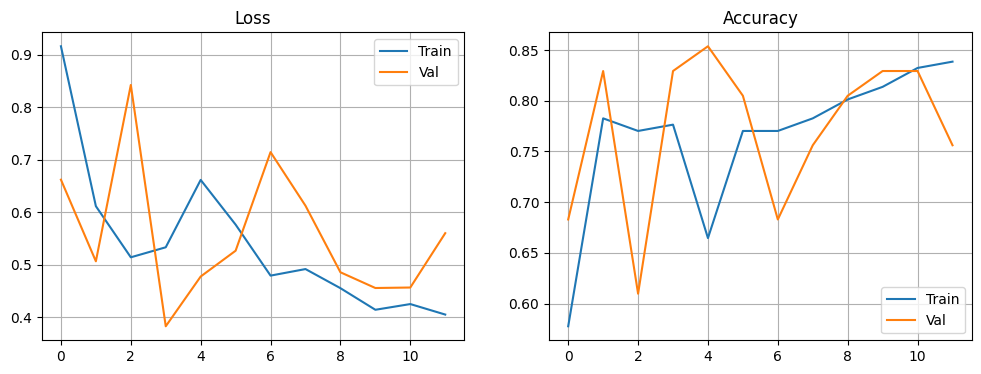

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()
plt.grid("on")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()
plt.grid("on")

plt.show()